# Understanding Customer Loyalty Through 100,000 Starbucks Orders

If you are a business, have you ever wondered who your most engaged, loyal customers are? Or how much of your customers are slipping away unbeknowst to you? 

Or...

If you are a consumer like me, have you ever wondered why you get emails about a rewards program or sudden discounts out of nowhere? 

There's a way to understand and figure out behind both these questions, and that's through the RFM model. Inspired by these questions, I analyzed 15,000 customers across 100,000 Starbucks orders to understand how the RFM model works, why it matters, and what it tells about my favorite drink's shop's customer base. 

### What is the RFM Model?
An RFM model (recency, frequency, and monetary) helps us to group customers into varying categories based on how recently they purchase, how often they purchase, and how much they spend on purchases. It helps businesses identify loyal customers, promising customers, and disengaged or inactive customers, and from there, they can tailor 
targeted outreach and communication to promote further happiness and satisfaction from customers or prevent at-risk customers from slipping away. 

The RFM model is inspired by the principle marketing rule: 80% of business outcomes come from 20% of its customers. Essentially, to grow your business, you must know your customers. And that is what the RFM model helps to address. 

Now, buckle up as we are about to dive into the customer base of Starbucks.

## Introduction

The data is sourced from Kaggle, created by Likitha Gedipud, and it simulates Starbucks ordering patterns across 100,000 purchases. It is a comprehensive dataset of 20 variables, but for the purpose of this analysis, I'll be only extracting the following variables:

1. customer_id
2. order_id
3. order_date
4. total_spend

In [2]:
# Accessing Dataset

import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import matplotlib.image as mpimg
import os


# Download latest version
path = kagglehub.dataset_download("likithagedipudi/starbucks-customer-ordering-patterns")

csv = os.listdir(path)

data = pd.read_csv(path + f'/{csv[0]}')


In [3]:
# Wrangling Data
data = data[['customer_id', 'order_id', 'order_date', 'total_spend']]

# What does my dataset include?
data.info()

# Are there missing data?
data.isna().sum()

# Dropping duplicates!
data.drop_duplicates()

data.head()


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   customer_id  100000 non-null  str    
 1   order_id     100000 non-null  str    
 2   order_date   100000 non-null  str    
 3   total_spend  100000 non-null  float64
dtypes: float64(1), str(3)
memory usage: 3.1 MB


,customer_id,order_id,order_date,total_spend
0,CUST_12974,ORD_00000001,2024-03-25,14.48
1,CUST_08235,ORD_00000002,2025-07-18,9.52
2,CUST_00393,ORD_00000003,2025-01-15,9.32
3,CUST_06936,ORD_00000004,2024-07-30,9.55
4,CUST_09800,ORD_00000005,2024-06-18,12.24


Let's prep our dataset for the RFM analysis. The dataset is clean and organized with no missing values, so we can proceed to feature engineering the three key variables we need. To do so, aggregating the dataset is needed. 

In [4]:
# Setting order_date as time
data['order_date'] = pd.to_datetime(data['order_date'])

# Feature-engineering to include Recency, Frequency, and Monetary:

# Finding the most recent date
most_recent_date = data.groupby('customer_id', as_index=False)['order_date'].max()

most_recent_date = most_recent_date['order_date'].max()

most_recent_date

# Aggregating to make the dataset appropriate for our analyses
rfm_data = data.groupby('customer_id', as_index=False).agg(
    {
        'order_date': lambda x: (most_recent_date - x.max()).days,
        'order_id': lambda x: x.nunique(),
        'total_spend': lambda x: x.sum()
    }
)

rfm_data.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']

# What does this new dataset include
rfm_data.info()

# Any missing values?
rfm_data.isna().sum()

# Let's see this data:
rfm_data.head()


<class 'pandas.DataFrame'>
RangeIndex: 14988 entries, 0 to 14987
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer ID  14988 non-null  str    
 1   Recency      14988 non-null  int64  
 2   Frequency    14988 non-null  int64  
 3   Monetary     14988 non-null  float64
dtypes: float64(1), int64(2), str(1)
memory usage: 468.5 KB


,Customer ID,Recency,Frequency,Monetary
0,CUST_00001,40,12,174.60
1,CUST_00002,61,13,207.18
2,CUST_00003,83,5,79.71
3,CUST_00004,145,7,95.85
4,CUST_00005,79,3,47.45


And now, our dataset is ready to be explored and analyzed.
## EDA

Starting of our exploratory data analysis, let's look at the descriptive statistics and distribution plots of our three variables. 

In [5]:
# Univariate Analyses
rfm_data.describe()


,Recency,Frequency,Monetary
count,14988.000000,14988.000000,14988.000000
mean,107.590072,6.672004,99.191158
std,105.032634,2.560401,40.965889
min,0.000000,1.000000,3.830000
25%,31.000000,5.000000,69.787500
50%,75.000000,6.000000,95.595000
75%,152.000000,8.000000,124.862500
max,727.000000,18.000000,301.680000


Text(0.5, 1.0, 'Distribution of Total Purchases')

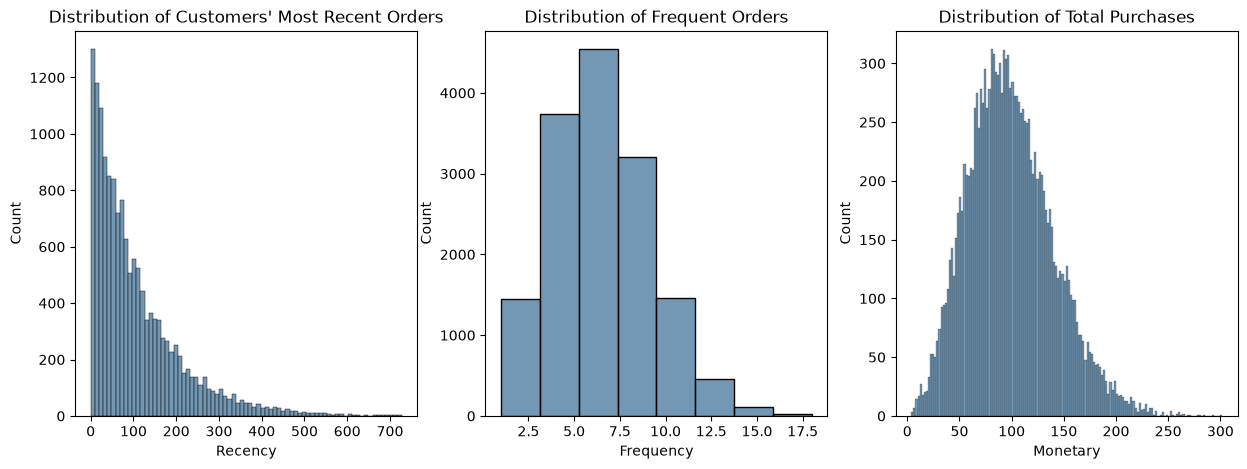

In [6]:

# RFM Histogram
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

recency_hist = sns.histplot(rfm_data['Recency'], color="#46769B", ax=axes[0])
axes[0].set_title("Distribution of Customers' Most Recent Orders")

frequency_hist = sns.histplot(rfm_data['Frequency'], color = "#46769B", binwidth=2, ax=axes[1])
axes[1].set_title("Distribution of Frequent Orders")

monetary_hist = sns.histplot(rfm_data['Monetary'], color = "#46769B", binwidth=2, ax=axes[2])
axes[2].set_title("Distribution of Total Purchases")


Here are key points to takeaway from these three histograms:

1. Majority of the customers have purchased something recently. This is shown by the distribution on the left, which is highly right skewed and peaks at 0.  

2. On average, most customers place around 5-10 orders all time, with several in the upper echelon of order frequency stretching out the right skewness.

3. Most customers spend around 100 bucks on alltime purchases, and as the pattern shows, there's several who spends way more than that.

Now that we have a rough idea of what our customers ordering patterns are in terms of recency, frequency, and monetary, let's take a step back and look at how these variables relate to one another given the data that we have. 

<Axes: >

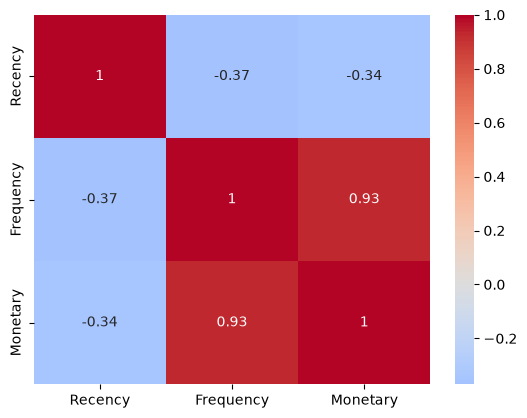

In [7]:
# Multivariate EDA: Correlation Heatmap
corr = rfm_data.select_dtypes('number').corr()

sns.heatmap(corr, cmap="coolwarm", annot=True, annot_kws={"size": 10}, center=0)

# Frequency and Monetary is highly positively correlated; Frequency and Recency is slightly inversely correlated; Monetary and Recency is slightly inversely correlated





Frequency and Monetary have a very high positive correlation. In other words, the more purchases one makes, the more they spend altogether. As expected. On the other hand, recency has moderate inverse relationships with both frequency and monetary. This makes sense, as one who's has just purchased something won't be likely to purchase anything until sometime later. Or it could also mean that we have a lot of newer customers, hence more combinations of high recency, low frequency and low monetary lead to such statistical outcome.

## RFM Analysis


In [8]:
# Building RFM pipeline

# Scoring Recency, Frequency, Monetary
rfm_data['Recency Score'] = pd.qcut(rfm_data['Recency'], 5, labels=[5,4,3,2,1])
rfm_data['Frequency Score'] = pd.qcut(rfm_data['Frequency'].rank(method = "first"), 5, labels = [1,2,3,4,5])
rfm_data['Monetary Score'] = pd.qcut(rfm_data['Monetary'], 5, labels = [1,2,3,4,5])

# Adding up Total Score: Given the correlation heatmap, I've decided to just score Recency and Frequency as Frequency is highly and positively correlated with Monetary
rfm_data['RFM Score'] = rfm_data['Recency Score'].astype('str') + rfm_data['Frequency Score'].astype('str')

# Dictionary to Map RFM Score to Corresponding Segment Label:
rfm_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3]': 'At Risk',
    r'[1-2][4-5]': 'Cannot Lose',
    r'3[1-3]': 'Need Attention',
    r'[3-4][4-5]': 'Loyal Customers',
    r'[4-5][1]': 'Newcomers',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]': 'Champions'
}

rfm_data['Customer Status'] = rfm_data['RFM Score'].replace(rfm_map, regex = True)

rfm_data.reset_index()

# Voila!
rfm_data.head()

,Customer ID,Recency,Frequency,Monetary,Recency Score,Frequency Score,Monetary Score,RFM Score,Customer Status
0,CUST_00001,40,12,174.60,4,5,5,45,Loyal Customers
1,CUST_00002,61,13,207.18,3,5,5,35,Loyal Customers
2,CUST_00003,83,5,79.71,3,1,2,31,Need Attention
3,CUST_00004,145,7,95.85,2,3,3,23,At Risk
4,CUST_00005,79,3,47.45,3,1,1,31,Need Attention


Now that we have constructed our RFM system, I've built a heatmap to illustrate what each of the ten statuses mean. 

Text(0.5, 1.0, 'RFM Segment Definitions')

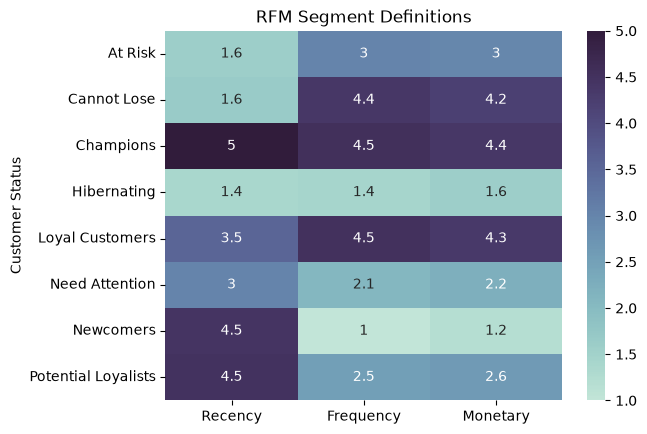

In [9]:
# Heat Map Aggregation Data
rfm_data['Recency Score'] = rfm_data['Recency Score'].astype(float)
rfm_data['Frequency Score'] = rfm_data['Frequency Score'].astype(float)
rfm_data['Monetary Score'] = rfm_data['Monetary Score'].astype(float)

rfm_characteristics = rfm_data.groupby('Customer Status', as_index= True).agg(
    Recency_Score=('Recency Score', 'mean'),
    Frequency_Score=('Frequency Score', 'mean'),
    Monetary_Score=('Monetary Score', 'mean')
)

rfm_characteristics.columns = ['Recency', 'Frequency', 'Monetary']

# Heatmap construction
sns.heatmap(rfm_characteristics, cmap= sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True), annot=True).set_title("RFM Segment Definitions")



#### RFM Segment Definitions

Champions score the highest on all three categories, indicating they are considered Starbuck's best customers. They tend to make frequent and recent purchases and spend more. 

- Loyal Customers are high spending customers who frequently make purchases.

- Potential Loyalists are customers who have been recently making more purchases. 

- Newcomers are new customers who have very recently made a purchase, hence they have not very high frequency or monetary scores.

- Promising customers show potential in becoming customers for Starbucks, as they've made a purchase pretty recently, although more monitoring and targeted marketing efforts should be made towards keeping them.

- Need Attention are customers who have made a purchase not too long ago and they make somewhat frequent purchases.

- Cannot Lose are customers who used to be highly engaged high spending customers. However they haven't been making a purchase a while now.

- At risk are customers who are slipping away. They haven't made a purchase for a while.

- Hibernating customers haven't made any purchase recently and also score low on frequency and monetary. They are high-risk customers for churnout.

Npw that our RFM system has categorized customers into their corresponding groups, we can analyze Starbucks customer base. To do that, I've built a treemap using Plotly:

### Starbucks Customer Base Breakdown

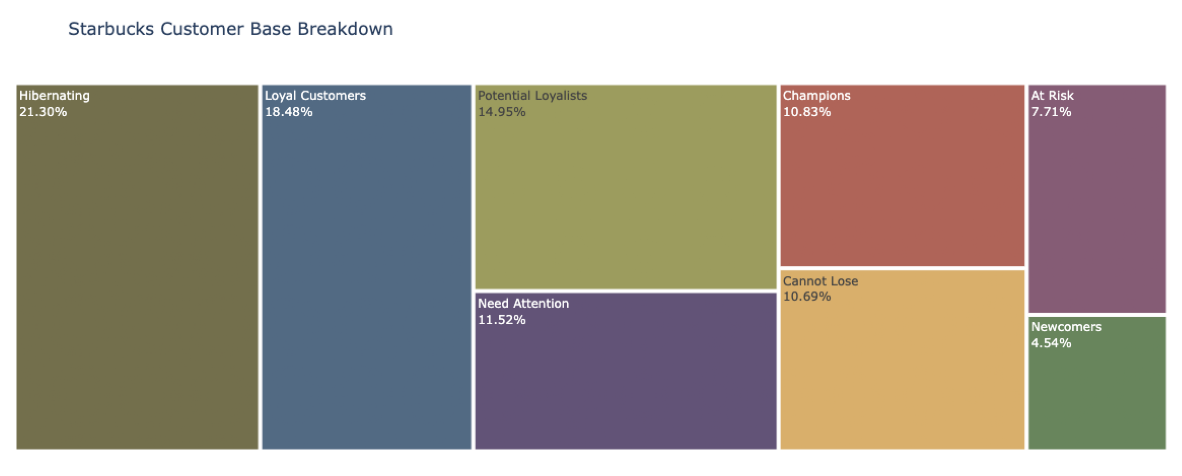

In [29]:
# Treemap aggregation data
treemap_data = rfm_data.groupby(['Customer Status'], as_index=False).size()
treemap_data['size'] = [round(i/len(rfm_data) * 100,2) for i in treemap_data['size']]

# Treemap construction with Plotly for interactivity
fig = px.treemap(treemap_data, path=['Customer Status'],
                 values='size', color='Customer Status', color_discrete_sequence=px.colors.qualitative.Antique, title = 'Starbucks Customer Base Breakdown')
fig.update_traces(
    texttemplate='%{label}<br>%{value:,.2f}%',
    textinfo="label+value")
fig.update_layout(margin = dict(t=50, l=0, r=0, b=10))


img = mpimg.imread('treemap.png')
plt.figure(figsize=(15, 15))
plt.imshow(img, aspect='equal')
plt.axis('off')
plt.show()



Starbucks' customer base is in need of reconnection. 

Already over 20% customers are dormant- that's like one out of five customers at the verge of churn! The combined proportion of the customer base who Starbucks cannot lose, need attention, or at risk of disengagement and hibernation is also very noticeable and alarming. It is very visible that efforts need for Starbucks to be made to re-engage with the customers and reforge the connection they once had that's slowly dimming away. 

On the other hand, we do have a good proportion of active customers. Over a quarter of our customer base are actively engaged with Starbucks, and approximately 15% show promise in becoming loyal customers. However that doesn't mean Starbucks should relax; they need to ensure that the current highly engaged customers remain content and satisfied, and should be rewarded appropriately. 

We also have a small proportion of newcomers, so Starbucks will also need to make sure to consistently monitor and nurture them for high retention rate. 



### What does it mean for Starbucks and what can Starbucks do?
In this hypothetical situation, Starbucks is in critical need to reestablish and maintain its relationship connection with its customer base. But how? Here are several suggested action steps they can take:

#### How Starbucks can reengage with customers who are at risk for churn or are slipping away:
1. Analyze to identify factors contributing to customers' disengagement
2. Tailor incentives such as discounts and free trials of products based off individual customers' purchase history
3. Frequent, personalized communication through texts and emails go a long way to winning customers back

#### How Starbucks can retain, recognize, and reward its highly engaged customers:
Champions: Provide value and recognition for their high engagement and contribution to the business. This includes offering exclusive offers, early access to products, opportunities for leadership involvement such as inviting them to beta tests and review products. 

Loyal Customers: Provide recognition for their engagement level through offering top-tier loyalty rewards, invitations to feature them on social media through testimonies/reviews, and reelaasing exclusive sneak-peeks to unreleased products.

Potential Loyalists: Continue rewarding and nurturing their engagement level. This includes sending invitations to be connected with company's social media platforms and incentivize deeper engagement through unlocking rewards through involvement with brand community. 

#### How Starbucks can maintain and nurture their new customers:
1. Ensure smooth onboarding and constant tailored communication with bonuses and perks to incentivize continued engagement.
2. Provide best possible customer service to make sure proper support and care is provided. 

### Conclusion
The RFM analysis of Starbucks order patterns reveal important insights about its customer base and allow us to see what direction Starbucks would have to take to manage their relationships with its customers and ultimately improve the business as a whole. However the analysis only takes recency, frequency, and monetary into consideration in understanding customers. That's not the only variables to knowing our customers; they do not capture entire variability of their ordering patterns. 

Additionally, the labels are created with my judgement and research. This introduces an inquiry I had during this analysis. What if I let an algorithm to categorize these customers? What differences or similarities would we see? And what if we let an algorithm cluster these customers on more than just these three variables? 

These are questions I will be addressing in the next part of my project.